<a href="https://colab.research.google.com/github/Lekanggy/Deeplearning-class/blob/master/RNN_Application_Variants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, SimpleRNN, Bidirectional
from tensorflow.keras.optimizers import Adam

Load market data

In [ ]:
df = yf.download("AAPL", period="5y", auto_adjust=True)[['Close']]
df.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2021-03-15,120.765724
2021-03-16,122.304626
2021-03-17,121.515678
2021-03-18,117.395683
2021-03-19,116.869728
2021-03-22,120.181335
2021-03-23,119.353416
2021-03-24,116.967125


In [ ]:
df.shape

(1256, 1)

In [ ]:
scaler = MinMaxScaler()
scale_data = scaler.fit_transform(df)
scale_data

array([[0.02355233],
       [0.0326507 ],
       [0.02798625],
       ...,
       [0.85152891],
       [0.82167203],
       [0.78832695]])

In [ ]:
def create_sequence(data, window=30):
  X, y = [], []
  for i in range(window, len(data)):
    X.append(data[i-window:i])
    y.append(data[i])
  return np.array(X), np.array(y)

window_size = 30
X, y = create_sequence(scale_data, window_size)

In [ ]:
X.shape

(1226, 30, 1)

In [ ]:
y.shape

(1226, 1)

In [ ]:
#Create a train test data
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (980, 30, 1)
X_test (246, 30, 1)
y_train (980, 1)
y_test (246, 1)


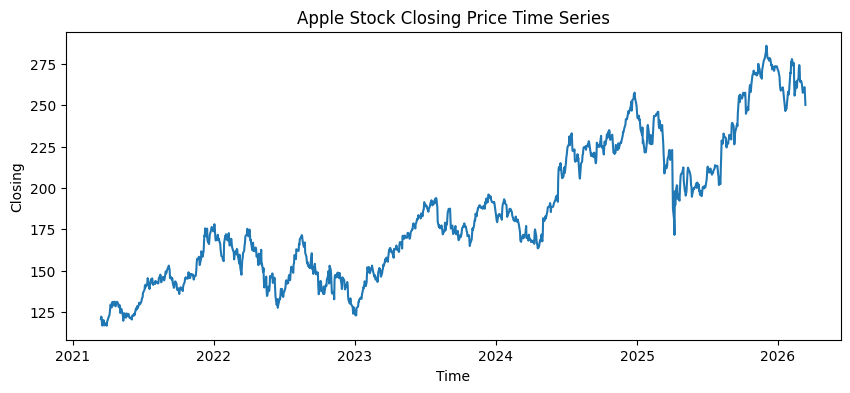

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df["Close"])
plt.title("Apple Stock Closing Price Time Series")
plt.xlabel("Time")
plt.ylabel("Closing")
plt.show();

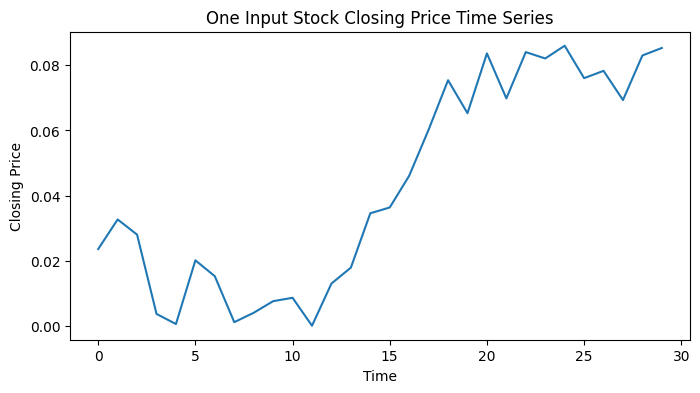

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(X[0])
plt.title("One Input Stock Closing Price Time Series")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show();

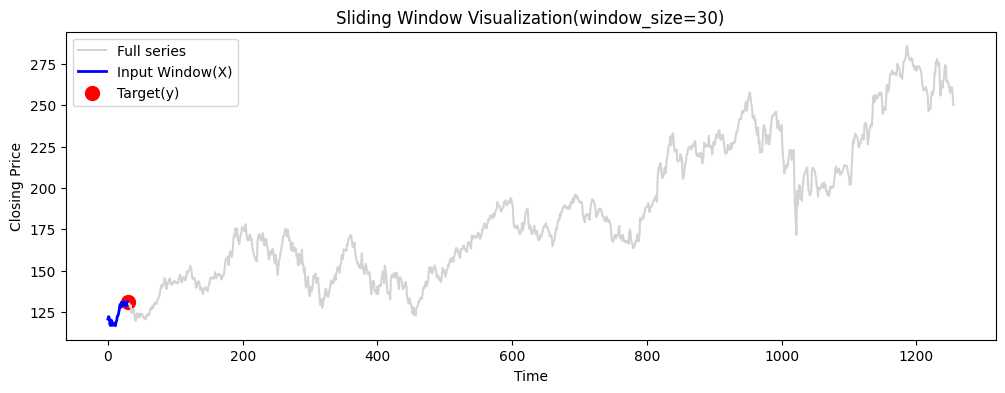

In [ ]:
i = 30
window_size = 30
plt.figure(figsize=(12, 4))

#Plot full seris
plt.plot(df["Close"].values, color='lightgray', label="Full series")

#Sliding window
plt.plot(range(i-window_size, i), df["Close"].values[i-window_size:i], color="blue", linewidth=2, label="Input Window(X)")

#Terget value
plt.scatter(i, df["Close"].values[i], color="red", s=100, label="Target(y)")
plt.title("Sliding Window Visualization(window_size=30)")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.show();

# Simple RNN

In [ ]:
model_rnn = Sequential([SimpleRNN(50, return_sequences=False, input_shape=(window_size, 1)), Dense(1)])
model_rnn.compile(optimizer="adam", loss="mse")
model_rnn.summary()

history_rnn = model_rnn.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0348 - val_loss: 0.0145
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019 - val_loss: 0.0047
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 9.7157e-04 - val_loss: 0.0035
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.3946e-04 - val_loss: 0.0026
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 7.9775e-04 - val_loss: 0.0024
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 7.8475e-04 - val_loss: 0.0029
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.2330e-04 - val_loss: 0.0024
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 7.2423e-04 - val_loss: 0.0019
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.8911e-04 - val_loss: 0.0019
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.7991e-04 - val_loss: 0.0020


In [ ]:
#Get the prediction
prediction = model_rnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [ ]:
actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
  print(f"Predicted: {prediction[i][0]:.2f}, Actual: {actual[i][0]:.2f}")

Predicted: 212.79, Actual: 217.32
Predicted: 215.96, Actual: 219.77
Predicted: 216.75, Actual: 222.78
Predicted: 217.79, Actual: 220.57
Predicted: 222.29, Actual: 222.88
Predicted: 219.42, Actual: 216.95
Predicted: 222.23, Actual: 221.17
Predicted: 220.58, Actual: 222.22
Predicted: 220.19, Actual: 222.92
Predicted: 223.66, Actual: 202.31
Predicted: 223.77, Actual: 187.56
Predicted: 212.60, Actual: 180.67
Predicted: 199.12, Actual: 171.67
Predicted: 185.33, Actual: 197.99
Predicted: 178.72, Actual: 189.59
Predicted: 186.16, Actual: 197.29
Predicted: 189.29, Actual: 201.64
Predicted: 194.29, Actual: 201.26
Predicted: 196.00, Actual: 193.43
Predicted: 202.49, Actual: 196.13
Predicted: 196.52, Actual: 192.32
Predicted: 195.93, Actual: 198.87
Predicted: 194.98, Actual: 203.71
Predicted: 193.82, Actual: 207.47
Predicted: 202.55, Actual: 208.37
Predicted: 206.21, Actual: 209.23
Predicted: 207.39, Actual: 210.29
Predicted: 216.45, Actual: 211.58
Predicted: 210.42, Actual: 212.39
Predicted: 212

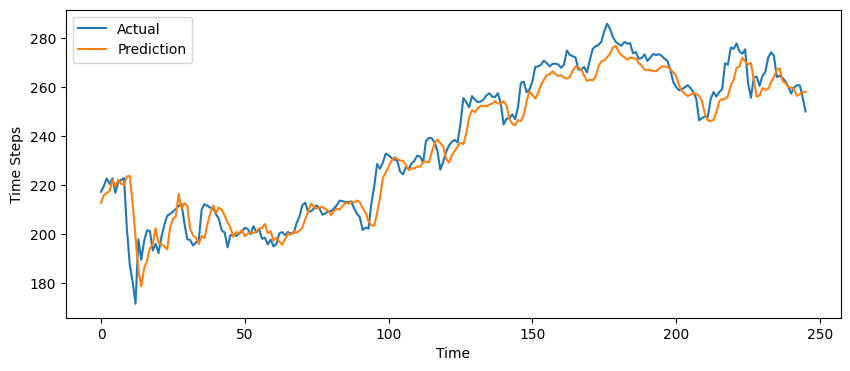

In [ ]:
#Plot the actual and the prediction
plt.figure(figsize=(10, 4))
plt.plot(actual, label="Actual")
plt.plot(prediction, label="Prediction")
plt.ylabel("Time Steps")
plt.xlabel("Time")
plt.legend()
plt.show()

# DEEP/STACK RNN

In [ ]:
model_deep = Sequential([SimpleRNN(50, return_sequences=True, input_shape=(window_size, 1)), SimpleRNN(50), Dense(1)])
model_deep.compile(optimizer="adam", loss="mse")
model_deep.summary()

history_deep = model_deep.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_14 (SimpleRNN)       │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.1151 - val_loss: 0.0112
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0036 - val_loss: 0.0107
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0014 - val_loss: 0.0076
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0012 - val_loss: 0.0044
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0011 - val_loss: 0.0059
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0010 - val_loss: 0.0048
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0011 - val_loss: 0.0045
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.1500e-04 - val_loss: 0.0042
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.0072e-04 - val_loss: 0.0030
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.1755e-04 - val_loss: 0.0032


# Bidirectional RNN

In [ ]:
model_bidirectional = Sequential([Bidirectional(SimpleRNN(50), input_shape=(window_size, 1)), Dense(1)])
model_bidirectional.compile(optimizer="adam", loss="mse")
model_bidirectional.summary()

history_bidirectional = model_bidirectional.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 100)            │         5,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0065 - val_loss: 0.0027
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0010 - val_loss: 0.0032
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.2054e-04 - val_loss: 0.0027
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.2338e-04 - val_loss: 0.0017
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.7659e-04 - val_loss: 0.0017
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.2846e-04 - val_loss: 0.0017
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.7775e-04 - val_loss: 0.0028
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.6773e-04 - val_loss: 0.0014
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 5.1377e-04 - val_loss: 0.0014
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.4151e-04 - val_loss: 0.0020


# STATEFUL RNN

In [ ]:
batch_size = 32
model_state_rnn = Sequential([Input(batch_shape=(batch_size, window_size, 1)), SimpleRNN(50, stateful=True), Dense(1)])
model_state_rnn.compile(optimizer="adam", loss="mse")
model_state_rnn.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_13 (SimpleRNN)       │ (32, 50)               │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (32, 1)                │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# In Stateful Rnn the training data length must be perfeectly divisible by the batch
batch = 32
train_len = int(len(X_train)) - int(len(X_train) % batch)
X_train_s = X_train[:train_len]
y_train_s = y_train[:train_len]
print("New Trainig shape", X_train_s.shape)

New Trainig shape (960, 30, 1)


In [ ]:
stateful_losses = []

for epoch in range(10):
  print(f"Epoch: {epoch+1}")
  history = model_state_rnn.fit(X_train_s, y_train_s, epochs=1, batch_size=batch, shuffle=False)

  #Store Loss
  stateful_losses.append(history.history['loss'][0])

  #Reset RNN Layers
  for layer in model_state_rnn.layers:
    if hasattr(layer, 'reset_states'):
      layer.reset_states()



Epoch: 1
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0146
Epoch: 2
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073
Epoch: 3
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030
Epoch: 4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016
Epoch: 5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014
Epoch: 6
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0012
Epoch: 7
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0011
Epoch: 8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010    
Epoch: 9
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.5554e-04
Epoch: 10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.1170e-04


# Plot Loss curve

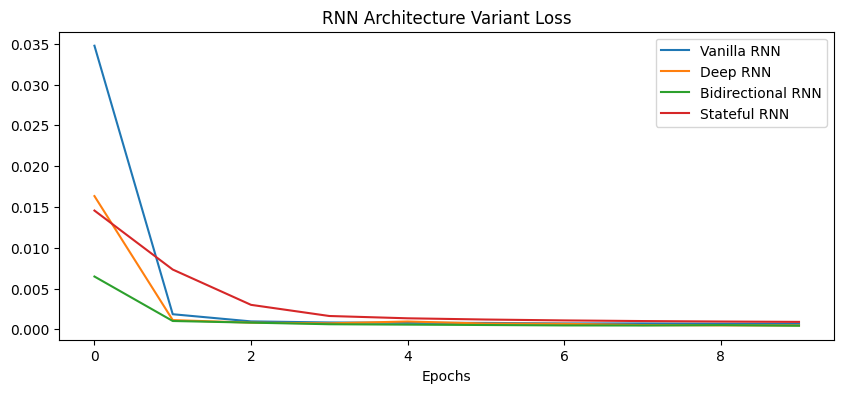

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_rnn.history['loss'], label="Vanilla RNN" )
plt.plot(history_deep.history['loss'], label="Deep RNN")
plt.plot(history_bidirectional.history['loss'], label="Bidirectional RNN")
plt.plot(stateful_losses, label="Stateful RNN")
plt.title("RNN Architecture Variant Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()